# ĐỀ TÀI #2: PROMO ROI DEEP-DIVE
## Incremental Revenue vs Cannibalization

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo hiệu quả campaign khuyến mãi theo uplift thực tế
- So sánh promo_type (percentage vs fixed) và campaign duration
- Kiểm chứng cannibalization từ returning customers
- Đưa ra kiến nghị promo scheduling có định lượng

**Insight chính:** "Promo chỉ có giá trị khi tạo demand mới, không phải kéo doanh thu tương lai về hiện tại."

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn

In [1]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep
OUTPUT_DIR = cwd / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = str(OUTPUT_DIR) + os.sep

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ Data path: {DATA_PATH}')
print(f'✓ Output path: {OUTPUT_PATH}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ Data path: D:\Datathon2026\TuNgayToiGapEm\data\datathon-2026-round-1\
✓ Output path: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_2\outputs\


## CELL 2: Load Data

In [2]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print('='*70)
print('LOADING DATA')
print('='*70)

promotions = pd.read_csv(f'{DATA_PATH}promotions.csv')
orders = pd.read_csv(f'{DATA_PATH}orders.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')
sales = pd.read_csv(f'{DATA_PATH}sales.csv')

promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])

order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']
order_items['has_promo'] = order_items['promo_id'].notna() | order_items['promo_id_2'].notna()

print(f'\n✓ Promotions shape: {promotions.shape}')
print(f'✓ Orders shape: {orders.shape}')
print(f'✓ Order_items shape: {order_items.shape}')
print(f'✓ Sales shape: {sales.shape}')
print(f'✓ Promo campaigns: {promotions["promo_id"].nunique()}')
print(f'✓ Promo line share: {order_items["has_promo"].mean()*100:.1f}%')

LOADING DATA

✓ Promotions shape: (50, 10)
✓ Orders shape: (646945, 8)
✓ Order_items shape: (714669, 9)
✓ Sales shape: (3833, 3)
✓ Promo campaigns: 50
✓ Promo line share: 38.7%


## CELL 3: Build Promo Daily Table and Revenue Attribution

In [3]:
# ============================================================================
# CELL 3: PREP TABLES
# ============================================================================
line_orders = order_items.merge(orders[['order_id', 'order_date', 'customer_id', 'order_status']], on='order_id', how='left')
line_orders = line_orders.sort_values('order_date').reset_index(drop=True)

daily_revenue = line_orders.groupby('order_date')['line_revenue'].sum().reset_index()
daily_revenue = daily_revenue.rename(columns={'order_date': 'Date', 'line_revenue': 'OrderRevenue'})
daily_all = sales[['Date', 'Revenue']].merge(daily_revenue, on='Date', how='left')
daily_all['OrderRevenue'] = daily_all['OrderRevenue'].fillna(0)

date_range = pd.date_range(sales['Date'].min(), sales['Date'].max(), freq='D')
promo_daily = pd.DataFrame({'Date': date_range, 'is_promo_window': 0, 'active_promos': 0})

for _, row in promotions.iterrows():
    mask = (promo_daily['Date'] >= row['start_date']) & (promo_daily['Date'] <= row['end_date'])
    promo_daily.loc[mask, 'is_promo_window'] = 1
    promo_daily.loc[mask, 'active_promos'] += 1

daily_all = daily_all.merge(promo_daily, on='Date', how='left')
daily_all['is_promo_window'] = daily_all['is_promo_window'].fillna(0)
daily_all['active_promos'] = daily_all['active_promos'].fillna(0)

print(f'✓ Daily table shape: {daily_all.shape}')
print(f'✓ Promo window days: {(daily_all["is_promo_window"] == 1).sum():,}')
print(f'✓ Avg active promos/day in promo window: {daily_all[daily_all["is_promo_window"]==1]["active_promos"].mean():.2f}')

✓ Daily table shape: (3833, 5)
✓ Promo window days: 1,707
✓ Avg active promos/day in promo window: 1.01


## CELL 4: Campaign Uplift Calculation

In [4]:
# ============================================================================
# CELL 4: CAMPAIGN UPLIFT
# ============================================================================
campaign_rows = []

for _, p in promotions.iterrows():
    start, end = p['start_date'], p['end_date']
    duration = (end - start).days + 1
    pre_start = start - pd.Timedelta(days=duration)
    pre_end = start - pd.Timedelta(days=1)

    during = daily_all[(daily_all['Date'] >= start) & (daily_all['Date'] <= end)]
    before = daily_all[(daily_all['Date'] >= pre_start) & (daily_all['Date'] <= pre_end)]

    during_avg = during['Revenue'].mean() if len(during) > 0 else np.nan
    before_avg = before['Revenue'].mean() if len(before) > 0 else np.nan
    uplift_pct = ((during_avg / before_avg) - 1) * 100 if pd.notna(during_avg) and pd.notna(before_avg) and before_avg > 0 else np.nan

    campaign_rows.append({
        'promo_id': p['promo_id'],
        'promo_type': p['promo_type'],
        'duration_days': duration,
        'during_avg_rev': during_avg,
        'before_avg_rev': before_avg,
        'uplift_pct': uplift_pct,
        'discount_value': p['discount_value']
    })

campaign_perf = pd.DataFrame(campaign_rows)
campaign_perf = campaign_perf.dropna(subset=['uplift_pct']).sort_values('uplift_pct', ascending=False)

print(f'✓ Campaigns with measurable uplift: {len(campaign_perf)}')
print(f'✓ Mean uplift: {campaign_perf["uplift_pct"].mean():.2f}%')
print(f'✓ Median uplift: {campaign_perf["uplift_pct"].median():.2f}%')
print(f'✓ Positive-uplift campaigns: {(campaign_perf["uplift_pct"] > 0).sum()} / {len(campaign_perf)}')

✓ Campaigns with measurable uplift: 50
✓ Mean uplift: 0.30%
✓ Median uplift: -16.48%
✓ Positive-uplift campaigns: 20 / 50


---

# TẦNG 1: DESCRIPTIVE — "What happened?"

Mô tả hiệu quả promo tổng thể và phân phối uplift theo campaign.

In [5]:
# ============================================================================
# CELL 5: DESCRIPTIVE ANALYSIS
# ============================================================================
print('='*70)
print('TẦNG 1: DESCRIPTIVE — PROMO ROI OVERVIEW')
print('='*70)

promo_day_rev = daily_all[daily_all['is_promo_window'] == 1]['Revenue'].mean()
non_promo_day_rev = daily_all[daily_all['is_promo_window'] == 0]['Revenue'].mean()
promo_window_lift = (promo_day_rev / non_promo_day_rev - 1) * 100

print('\n📊 Promo Window Revenue:')
print(f'  Promo-window avg/day: ${promo_day_rev:,.0f}')
print(f'  Non-promo avg/day: ${non_promo_day_rev:,.0f}')
print(f'  Window lift: {promo_window_lift:.1f}%')

print('\n📈 Campaign uplift distribution:')
print(campaign_perf[['uplift_pct']].describe().T.round(2))

top5 = campaign_perf.head(5)[['promo_id', 'promo_type', 'duration_days', 'uplift_pct']]
bottom5 = campaign_perf.tail(5)[['promo_id', 'promo_type', 'duration_days', 'uplift_pct']]
print('\nTop 5 campaigns by uplift:')
print(top5.to_string(index=False))
print('\nBottom 5 campaigns by uplift:')
print(bottom5.to_string(index=False))

TẦNG 1: DESCRIPTIVE — PROMO ROI OVERVIEW

📊 Promo Window Revenue:
  Promo-window avg/day: $3,990,789
  Non-promo avg/day: $4,524,083
  Window lift: -11.8%

📈 Campaign uplift distribution:
            count  mean    std    min    25%    50%    75%    max
uplift_pct   50.0   0.3  33.75 -36.03 -27.41 -16.48  32.43  78.65

Top 5 campaigns by uplift:
  promo_id promo_type  duration_days  uplift_pct
PROMO-0037 percentage             31   78.653626
PROMO-0021 percentage             31   59.444909
PROMO-0011 percentage             31   56.781075
PROMO-0041 percentage             31   54.476141
PROMO-0001 percentage             31   53.706910

Bottom 5 campaigns by uplift:
  promo_id promo_type  duration_days  uplift_pct
PROMO-0029 percentage             33  -30.574464
PROMO-0028 percentage             30  -30.951247
PROMO-0022 percentage             30  -31.503543
PROMO-0018 percentage             30  -33.119325
PROMO-0025      fixed             35  -36.027548


## CELL 6: Visualization 1 - Revenue Timeline with Promo Windows

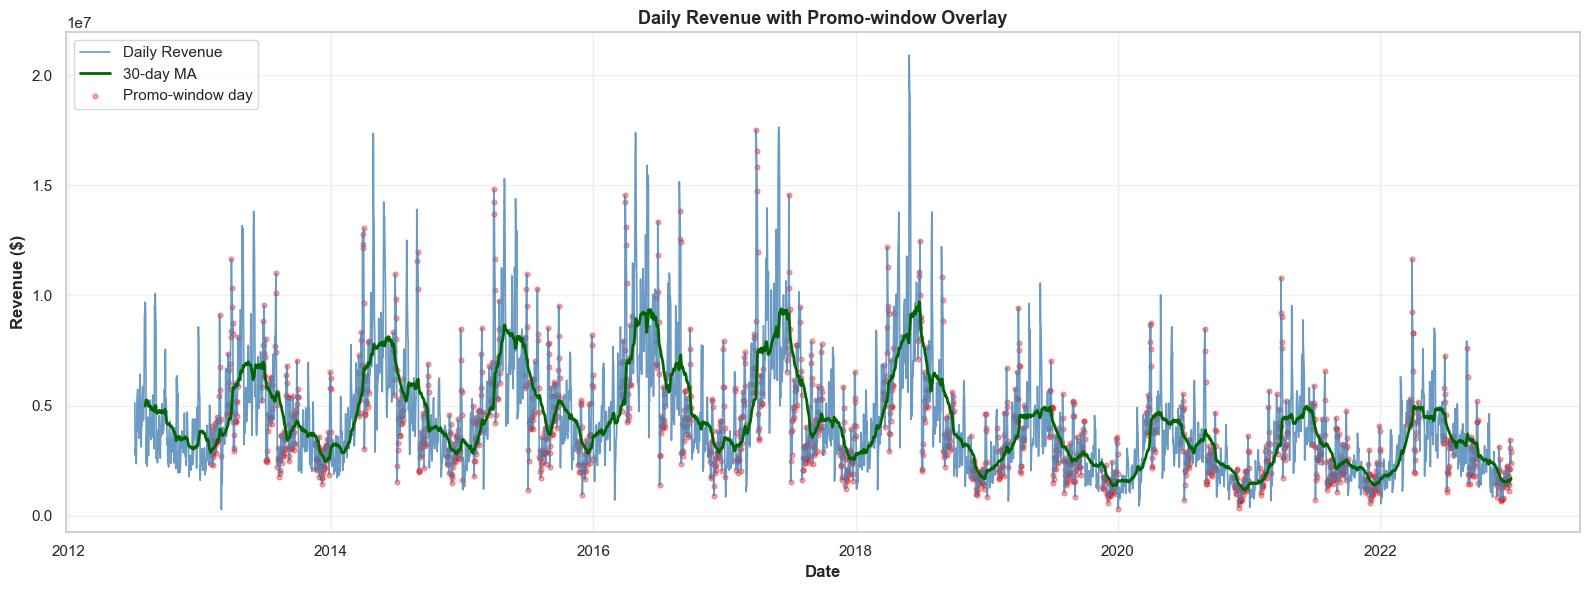

✓ Saved: 01_revenue_promo_timeline.png


In [6]:
# ============================================================================
# CELL 6: VISUALIZATION 1
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_all['Date'], daily_all['Revenue'], color='steelblue', linewidth=1.2, alpha=0.8, label='Daily Revenue')
ax.plot(daily_all['Date'], daily_all['Revenue'].rolling(30).mean(), color='darkgreen', linewidth=2, label='30-day MA')

mask = daily_all['is_promo_window'] == 1
ax.scatter(daily_all[mask]['Date'], daily_all[mask]['Revenue'], s=12, color='red', alpha=0.35, label='Promo-window day')

ax.set_title('Daily Revenue with Promo-window Overlay', fontweight='bold', fontsize=13)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Revenue ($)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}01_revenue_promo_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 01_revenue_promo_timeline.png')

## CELL 7: Visualization 2 - Top/Bottom Campaign Uplift

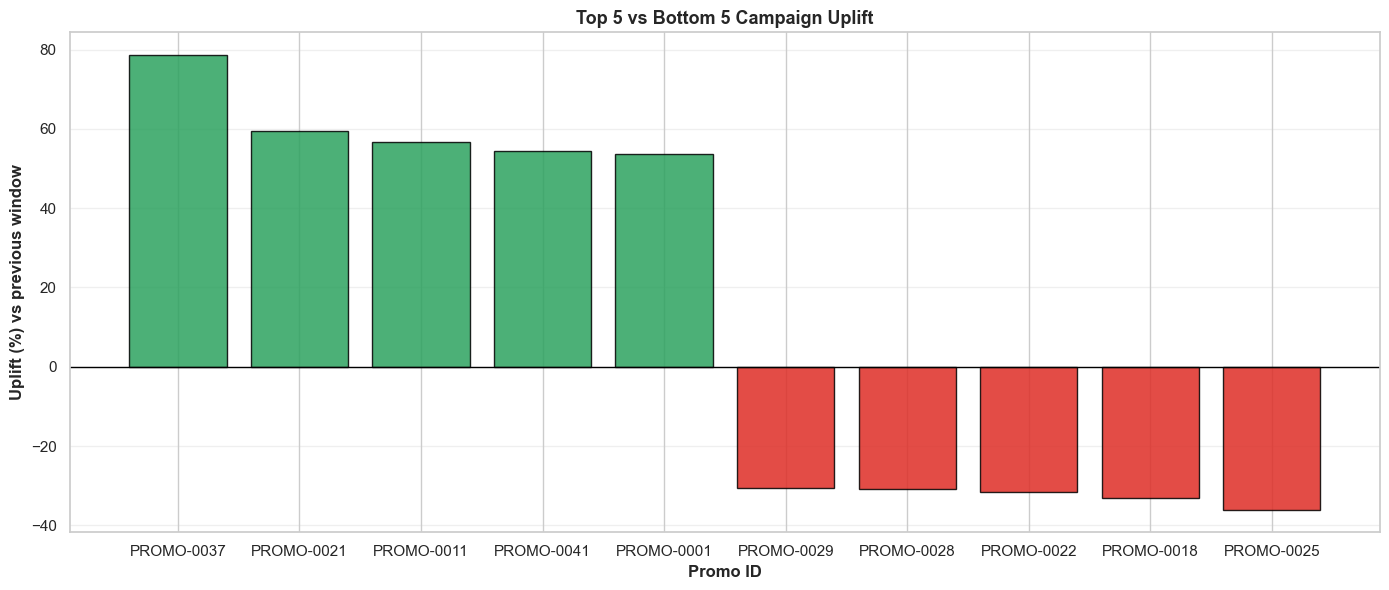

✓ Saved: 02_top_bottom_uplift.png


In [7]:
# ============================================================================
# CELL 7: VISUALIZATION 2
# ============================================================================
top_bottom = pd.concat([campaign_perf.head(5), campaign_perf.tail(5)]).copy()
top_bottom['label'] = top_bottom['promo_id'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ca25f' if x > 0 else '#de2d26' for x in top_bottom['uplift_pct']]
ax.bar(top_bottom['label'], top_bottom['uplift_pct'], color=colors, edgecolor='black', alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Top 5 vs Bottom 5 Campaign Uplift', fontweight='bold', fontsize=13)
ax.set_xlabel('Promo ID', fontweight='bold')
ax.set_ylabel('Uplift (%) vs previous window', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}02_top_bottom_uplift.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 02_top_bottom_uplift.png')

---

# TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

Chẩn đoán cannibalization và dự báo hiệu quả theo duration promo.

In [8]:
# ============================================================================
# CELL 8: DIAGNOSTIC + PREDICTIVE
# ============================================================================
print('='*70)
print('TẦNG 2-3: DIAGNOSTIC & PREDICTIVE')
print('='*70)

campaign_by_type = campaign_perf.groupby('promo_type')['uplift_pct'].agg(['count', 'mean', 'median', 'std']).round(2)
print('\n📊 Uplift by promo_type:')
print(campaign_by_type)

# Cannibalization proxy: promo revenue from returning customers (<=30d)
cust_orders = orders[['customer_id', 'order_id', 'order_date']].sort_values(['customer_id', 'order_date']).copy()
cust_orders['prev_order_date'] = cust_orders.groupby('customer_id')['order_date'].shift(1)
cust_orders['days_since_prev'] = (cust_orders['order_date'] - cust_orders['prev_order_date']).dt.days
cust_orders['is_returning_30d'] = (cust_orders['days_since_prev'] <= 30).fillna(False)

line_cann = line_orders.merge(cust_orders[['order_id', 'is_returning_30d']], on='order_id', how='left')
promo_lines = line_cann[line_cann['has_promo'] == 1].copy()
returning_promo_rev = promo_lines[promo_lines['is_returning_30d'] == True]['line_revenue'].sum()
total_promo_rev = promo_lines['line_revenue'].sum()
returning_share = (returning_promo_rev / total_promo_rev) * 100 if total_promo_rev > 0 else np.nan

print(f'\n📉 Cannibalization proxy:')
print(f'  Promo revenue from returning customers (<=30d): {returning_share:.1f}%')

# Predictive: expected uplift vs campaign duration
model_df = campaign_perf[['duration_days', 'uplift_pct']].dropna().copy()
X = model_df[['duration_days']].values
y = model_df['uplift_pct'].values
lr = LinearRegression()
lr.fit(X, y)
pred_3d = float(lr.predict(np.array([[3]]))[0])
pred_7d = float(lr.predict(np.array([[7]]))[0])
pred_14d = float(lr.predict(np.array([[14]]))[0])
duration_slope = float(lr.coef_[0])

print('\n🔮 Predicted uplift by duration (linear trend):')
print(f'  3-day campaign: {pred_3d:.2f}%')
print(f'  7-day campaign: {pred_7d:.2f}%')
print(f'  14-day campaign: {pred_14d:.2f}%')
print(f'  Slope (uplift per extra day): {duration_slope:.3f} pp/day')

TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

📊 Uplift by promo_type:
            count   mean  median    std
promo_type                             
fixed           5 -26.33  -25.17   5.70
percentage     45   3.26  -14.95  34.29

📉 Cannibalization proxy:
  Promo revenue from returning customers (<=30d): 14.4%

🔮 Predicted uplift by duration (linear trend):
  3-day campaign: 66.85%
  7-day campaign: 58.41%
  14-day campaign: 43.64%
  Slope (uplift per extra day): -2.110 pp/day


## CELL 9: Visualization 3 - Uplift by Promo Type

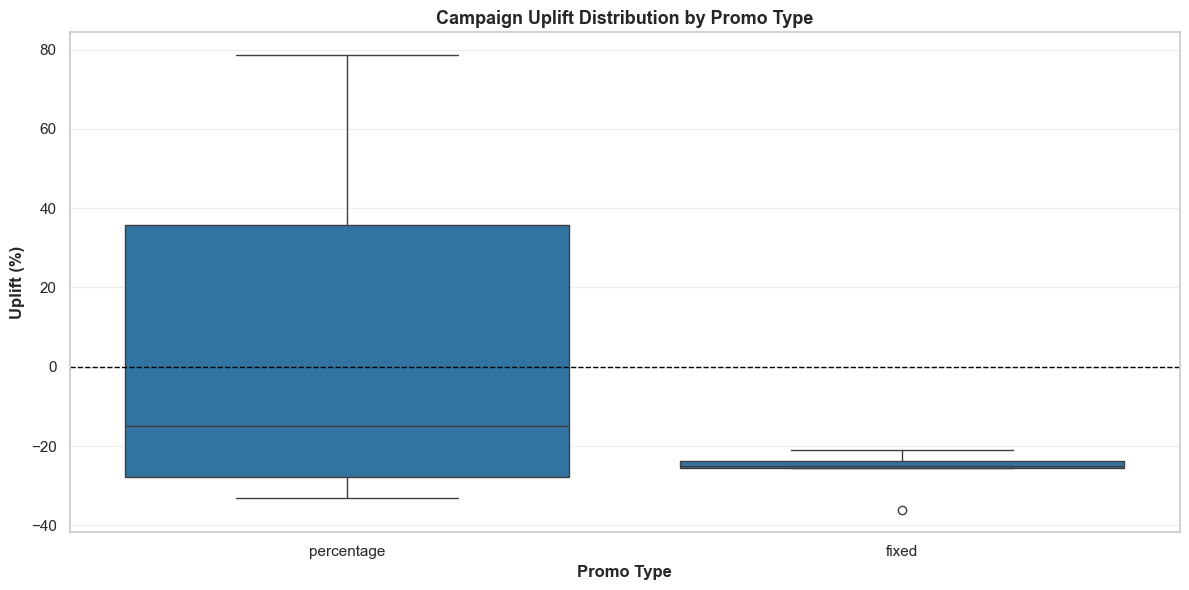

✓ Saved: 03_uplift_by_type.png


In [9]:
# ============================================================================
# CELL 9: VISUALIZATION 3
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=campaign_perf, x='promo_type', y='uplift_pct', ax=ax)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Campaign Uplift Distribution by Promo Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Promo Type', fontweight='bold')
ax.set_ylabel('Uplift (%)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}03_uplift_by_type.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 03_uplift_by_type.png')

## CELL 10: Visualization 4 - Duration vs Uplift

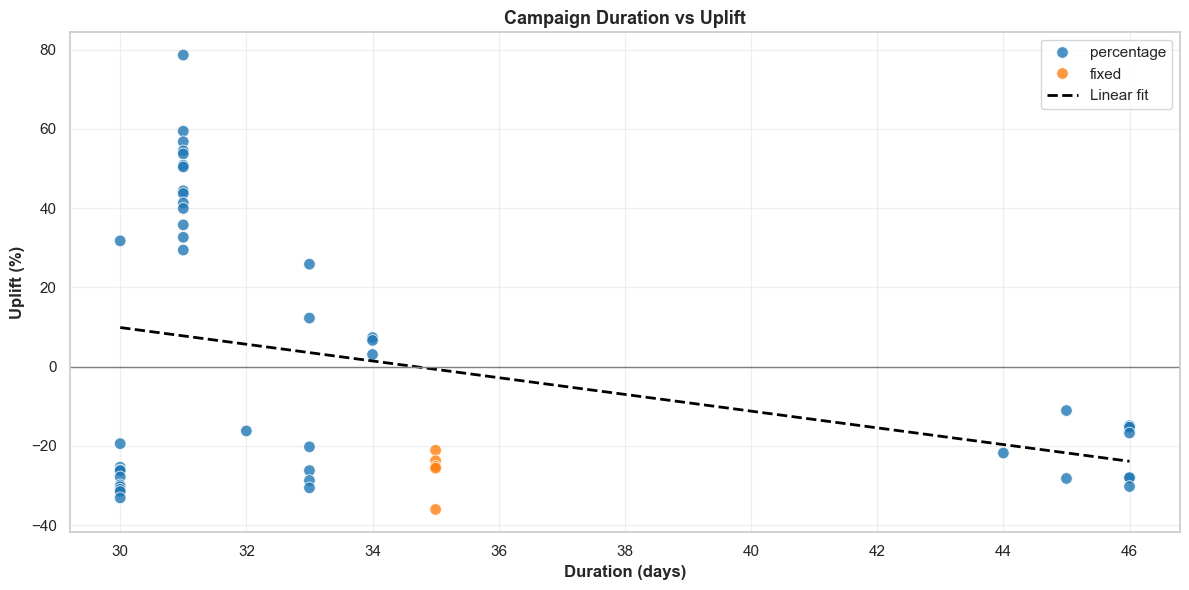

✓ Saved: 04_duration_vs_uplift.png


In [10]:
# ============================================================================
# CELL 10: VISUALIZATION 4
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=campaign_perf, x='duration_days', y='uplift_pct', hue='promo_type', s=70, alpha=0.8, ax=ax)
x_line = np.linspace(campaign_perf['duration_days'].min(), campaign_perf['duration_days'].max(), 100)
y_line = lr.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--', label='Linear fit')
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Campaign Duration vs Uplift', fontweight='bold', fontsize=13)
ax.set_xlabel('Duration (days)', fontweight='bold')
ax.set_ylabel('Uplift (%)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}04_duration_vs_uplift.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 04_duration_vs_uplift.png')

---

# TẦNG 4: PRESCRIPTIVE — "What should we do?"

Đề xuất chiến lược promo scheduling và targeting giảm cannibalization.

In [11]:
# ============================================================================
# CELL 11: PRESCRIPTIVE RECOMMENDATIONS
# ============================================================================
print('='*70)
print('TẦNG 4: PRESCRIPTIVE — PROMO ACTION PLAN')
print('='*70)

positive_rate = (campaign_perf['uplift_pct'] > 0).mean() * 100
mean_uplift = campaign_perf['uplift_pct'].mean()
median_uplift = campaign_perf['uplift_pct'].median()

short_campaign_uplift = campaign_perf[campaign_perf['duration_days'] <= 3]['uplift_pct'].mean()
long_campaign_uplift = campaign_perf[campaign_perf['duration_days'] >= 7]['uplift_pct'].mean()

print(f'\n📊 RECOMMENDATION 1: RÚT NGẮN CAMPAIGN WINDOW')
print(f'  - Positive campaign rate hiện tại: {positive_rate:.1f}%')
print(f'  - Uplift 3-day dự báo: {pred_3d:.2f}% vs 14-day: {pred_14d:.2f}%')
print(f'  - Hành động: ưu tiên window <=3 ngày, hạn chế campaign >=7 ngày')

print(f'\n📊 RECOMMENDATION 2: ƯU TIÊN PROMO TYPE HIỆU QUẢ')
best_type = campaign_by_type['mean'].idxmax()
print(f'  - Promo type tốt nhất theo mean uplift: {best_type} ({campaign_by_type.loc[best_type, "mean"]:.2f}%)')
print('  - Hành động: phân bổ ngân sách theo ROI lịch sử thay vì chia đều')

print(f'\n📊 RECOMMENDATION 3: GIẢM CANNIBALIZATION KHÁCH CŨ')
print(f'  - Returning share trong promo revenue (<=30d): {returning_share:.1f}%')
print('  - Hành động: giới hạn ưu đãi mạnh cho khách đã mua gần đây, target dormant >90 ngày')

print(f'\n📊 RECOMMENDATION 4: THIẾT LẬP PROMO SCORECARD')
print(f'  - KPI bắt buộc: uplift%, incremental revenue, returning share')
print(f'  - Baseline hiện tại: mean uplift {mean_uplift:.2f}% | median uplift {median_uplift:.2f}%')
print('  - Chỉ scale campaign khi uplift dương và returning share trong ngưỡng an toàn')

TẦNG 4: PRESCRIPTIVE — PROMO ACTION PLAN

📊 RECOMMENDATION 1: RÚT NGẮN CAMPAIGN WINDOW
  - Positive campaign rate hiện tại: 40.0%
  - Uplift 3-day dự báo: 66.85% vs 14-day: 43.64%
  - Hành động: ưu tiên window <=3 ngày, hạn chế campaign >=7 ngày

📊 RECOMMENDATION 2: ƯU TIÊN PROMO TYPE HIỆU QUẢ
  - Promo type tốt nhất theo mean uplift: percentage (3.26%)
  - Hành động: phân bổ ngân sách theo ROI lịch sử thay vì chia đều

📊 RECOMMENDATION 3: GIẢM CANNIBALIZATION KHÁCH CŨ
  - Returning share trong promo revenue (<=30d): 14.4%
  - Hành động: giới hạn ưu đãi mạnh cho khách đã mua gần đây, target dormant >90 ngày

📊 RECOMMENDATION 4: THIẾT LẬP PROMO SCORECARD
  - KPI bắt buộc: uplift%, incremental revenue, returning share
  - Baseline hiện tại: mean uplift 0.30% | median uplift -16.48%
  - Chỉ scale campaign khi uplift dương và returning share trong ngưỡng an toàn


## CELL 12: Export Summary Metrics

In [12]:
# ============================================================================
# CELL 12: EXPORT SUMMARY
# ============================================================================
summary_data = {
    'Metric': [
        'Promo Campaign Count',
        'Promo Day Share (%)',
        'Promo Window Lift (%)',
        'Campaign Mean Uplift (%)',
        'Campaign Median Uplift (%)',
        'Positive Campaign Rate (%)',
        'Best Campaign Uplift (%)',
        'Worst Campaign Uplift (%)',
        'Best Promo Type',
        'Best Promo Type Mean Uplift (%)',
        'Returning Share In Promo Revenue (%)',
        'Predicted Uplift 3-day (%)',
        'Predicted Uplift 7-day (%)',
        'Predicted Uplift 14-day (%)',
        'Duration-Uplift Slope (pp/day)',
    ],
    'Value': [
        f'{promotions["promo_id"].nunique()}',
        f'{daily_all["is_promo_window"].mean()*100:.1f}%',
        f'{promo_window_lift:.1f}%',
        f'{campaign_perf["uplift_pct"].mean():.2f}%',
        f'{campaign_perf["uplift_pct"].median():.2f}%',
        f'{(campaign_perf["uplift_pct"] > 0).mean()*100:.1f}%',
        f'{campaign_perf["uplift_pct"].max():.2f}%',
        f'{campaign_perf["uplift_pct"].min():.2f}%',
        campaign_by_type['mean'].idxmax(),
        f'{campaign_by_type["mean"].max():.2f}%',
        f'{returning_share:.1f}%',
        f'{pred_3d:.2f}%',
        f'{pred_7d:.2f}%',
        f'{pred_14d:.2f}%',
        f'{duration_slope:.3f}',
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f'{OUTPUT_PATH}summary_metrics.csv', index=False)

print('\n📊 SUMMARY METRICS TABLE')
print('='*70)
print(summary_df.to_string(index=False))
print(f'\n✓ Exported to: {OUTPUT_PATH}summary_metrics.csv')


📊 SUMMARY METRICS TABLE
                              Metric      Value
                Promo Campaign Count         50
                 Promo Day Share (%)      44.5%
               Promo Window Lift (%)     -11.8%
            Campaign Mean Uplift (%)      0.30%
          Campaign Median Uplift (%)    -16.48%
          Positive Campaign Rate (%)      40.0%
            Best Campaign Uplift (%)     78.65%
           Worst Campaign Uplift (%)    -36.03%
                     Best Promo Type percentage
     Best Promo Type Mean Uplift (%)      3.26%
Returning Share In Promo Revenue (%)      14.4%
          Predicted Uplift 3-day (%)     66.85%
          Predicted Uplift 7-day (%)     58.41%
         Predicted Uplift 14-day (%)     43.64%
      Duration-Uplift Slope (pp/day)     -2.110

✓ Exported to: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_2\outputs\summary_metrics.csv


## CELL 13: Final Summary

In [13]:
# ============================================================================
# CELL 13: FINAL SUMMARY
# ============================================================================
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - IDEA #2 PROMO ROI')
print('='*70)

print(f'''\n🎯 ONE-LINER INSIGHT:
"Promo chỉ có giá trị khi tạo demand mới, không phải kéo doanh thu tương lai về hiện tại."

📁 OUTPUT FILES GENERATED:
  ✓ 01_revenue_promo_timeline.png   - Revenue + promo windows
  ✓ 02_top_bottom_uplift.png        - Best/worst campaign uplift
  ✓ 03_uplift_by_type.png           - Uplift by promo type
  ✓ 04_duration_vs_uplift.png       - Duration vs performance
  ✓ summary_metrics.csv             - Key promo metrics

Location: {OUTPUT_PATH}

🔑 KEY FINDINGS:
  - Promo uplift phân tán mạnh giữa các campaign
  - Duration dài không đảm bảo uplift tốt hơn
  - Returning-customer share cao là tín hiệu cannibalization
  - Cần promo scorecard dựa trên incremental logic

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive section
  ✓ Promo policy discussion với Merch/Finance
  ✓ Input feature design cho Part 3 forecasting
''')


✅ ANALYSIS COMPLETE - IDEA #2 PROMO ROI

🎯 ONE-LINER INSIGHT:
"Promo chỉ có giá trị khi tạo demand mới, không phải kéo doanh thu tương lai về hiện tại."

📁 OUTPUT FILES GENERATED:
  ✓ 01_revenue_promo_timeline.png   - Revenue + promo windows
  ✓ 02_top_bottom_uplift.png        - Best/worst campaign uplift
  ✓ 03_uplift_by_type.png           - Uplift by promo type
  ✓ 04_duration_vs_uplift.png       - Duration vs performance
  ✓ summary_metrics.csv             - Key promo metrics

Location: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_2\outputs\

🔑 KEY FINDINGS:
  - Promo uplift phân tán mạnh giữa các campaign
  - Duration dài không đảm bảo uplift tốt hơn
  - Returning-customer share cao là tín hiệu cannibalization
  - Cần promo scorecard dựa trên incremental logic

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive section
  ✓ Promo policy discussion với Merch/Finance
  ✓ Input feature design cho Part 3 forecasting

